# Exploración numérica temporal
Esta libreta resume la evolución temporal de divorcios y violencia intrafamiliar (VIF)
por año y departamento, además de resaltar variaciones recientes y combinaciones
Departamento–Año extremas.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp

panel = dp.build_panel(force_rebuild=False).dropna(subset=['departamento', 'anio']).copy()

## Totales anuales
Se suman los casos por año para observar tendencia macro.

,anio,divorcios_total,vif_total
0,2000,0.0,4
1,2001,0.0,18
2,2002,0.0,7
3,2003,0.0,8
4,2004,0.0,14


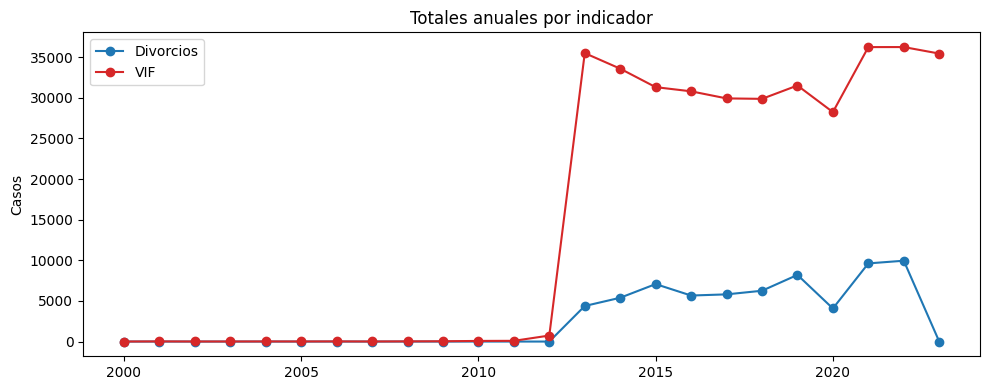

In [2]:
totales_anuales = panel.groupby('anio')[['divorcios_total', 'vif_total']].sum().reset_index()
display(totales_anuales.head())
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(totales_anuales['anio'], totales_anuales['divorcios_total'], marker='o', label='Divorcios')
ax.plot(totales_anuales['anio'], totales_anuales['vif_total'], marker='o', label='VIF', color='#d62728')
ax.set_ylabel('Casos')
ax.set_title('Totales anuales por indicador')
ax.legend()
plt.tight_layout()

## Variación interanual desde 2020
Se calculan variaciones porcentuales para resaltar repuntes y caídas en el periodo reciente.

,anio,divorcios_total,vif_total
0,2020,-50.3,-10.4
1,2021,136.2,28.3
2,2022,3.4,0.0
3,2023,-100.0,-2.2


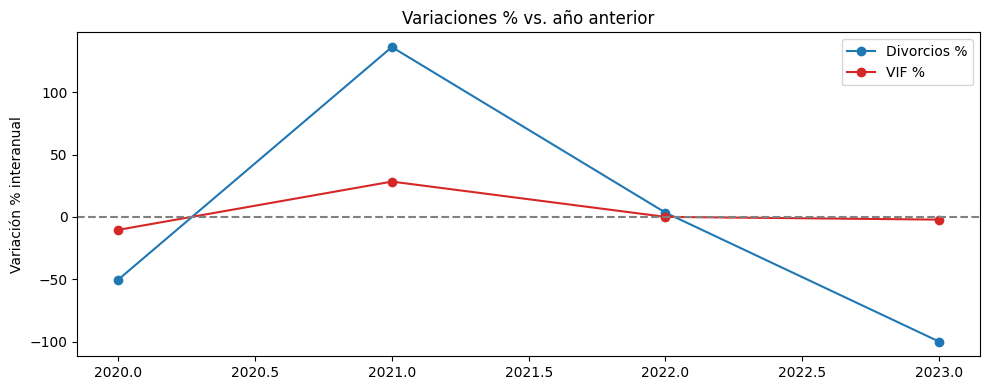

In [3]:
variaciones = totales_anuales.set_index('anio').pct_change().loc[2020:] * 100
variaciones = variaciones.round(1).reset_index()
display(variaciones)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(variaciones['anio'], variaciones['divorcios_total'], marker='o', label='Divorcios %')
ax.plot(variaciones['anio'], variaciones['vif_total'], marker='o', label='VIF %', color='#d62728')
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Variación % interanual')
ax.set_title('Variaciones % vs. año anterior')
ax.legend()
plt.tight_layout()

## Heatmaps Departamento × Año
Se contrastan divorcios y VIF total para identificar focos persistentes en el tiempo.

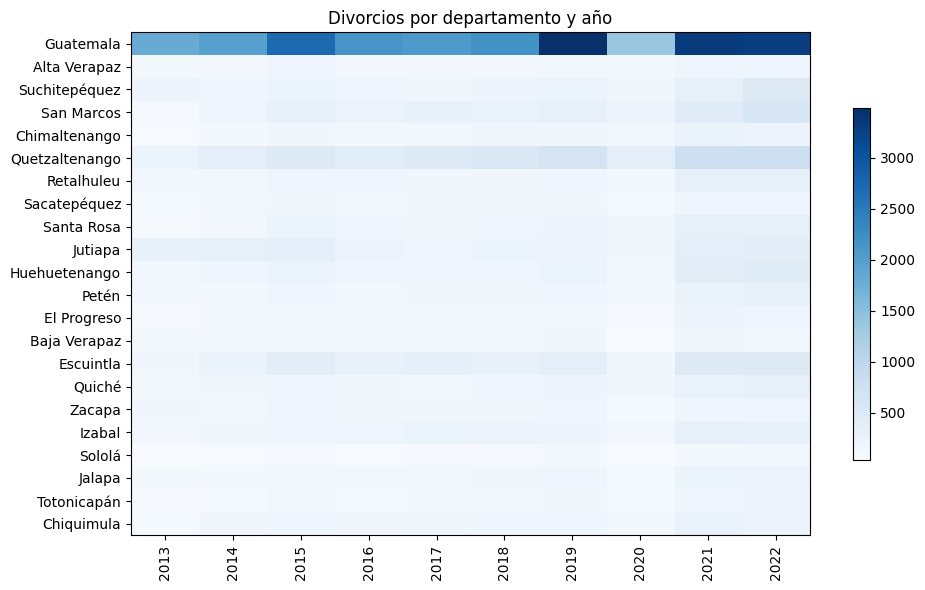

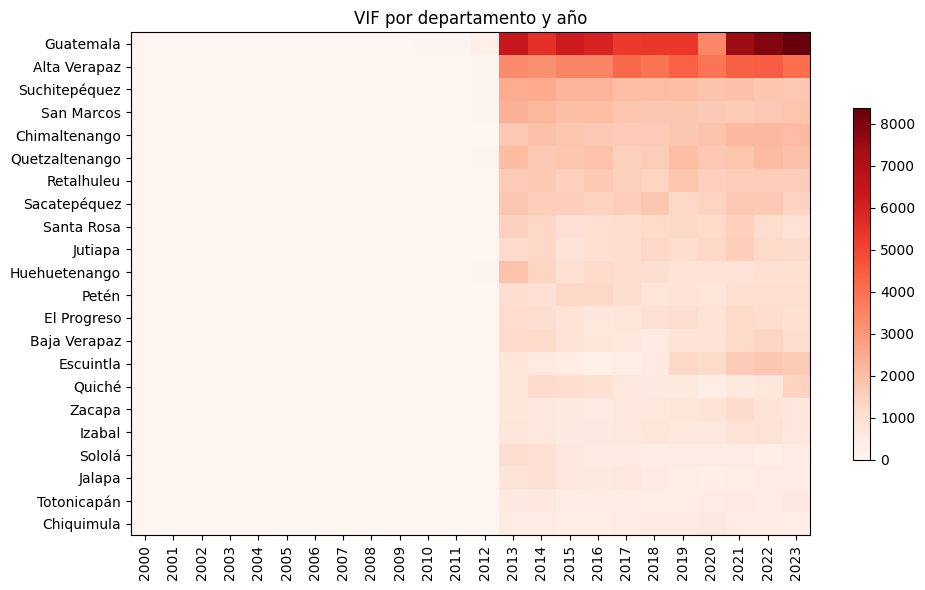

In [4]:
departamento_orden = panel.groupby('departamento')['vif_total'].sum().sort_values(ascending=False).index
heatmap_vif = panel.pivot_table(index='departamento', columns='anio', values='vif_total', fill_value=0).loc[departamento_orden]
heatmap_div = panel.pivot_table(index='departamento', columns='anio', values='divorcios_total', fill_value=0).loc[departamento_orden]

def dibujar_heatmap(matriz: pd.DataFrame, titulo: str, cmap: str):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(matriz, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(matriz.columns)))
    ax.set_xticklabels(matriz.columns, rotation=90)
    ax.set_yticks(range(len(matriz.index)))
    ax.set_yticklabels(matriz.index)
    ax.set_title(titulo)
    fig.colorbar(im, ax=ax, shrink=0.7)
    plt.tight_layout()

dibujar_heatmap(heatmap_div, 'Divorcios por departamento y año', 'Blues')
dibujar_heatmap(heatmap_vif, 'VIF por departamento y año', 'Reds')

## Combinaciones extremas Departamento–Año
Se listan los pares con mayor número de casos para orientar el análisis cualitativo.

In [5]:
top_div = panel.sort_values('divorcios_total', ascending=False).head(10)[['departamento', 'anio', 'divorcios_total']]
top_vif = panel.sort_values('vif_total', ascending=False).head(10)[['departamento', 'anio', 'vif_total']]
display(top_div)
display(top_vif)

,departamento,anio,divorcios_total
247,Guatemala,2019,3491.0
291,Guatemala,2021,3339.0
313,Guatemala,2022,3295.0
159,Guatemala,2015,2707.0
225,Guatemala,2018,2185.0
181,Guatemala,2016,2142.0
203,Guatemala,2017,2075.0
137,Guatemala,2014,1980.0
115,Guatemala,2013,1803.0
269,Guatemala,2020,1361.0


,departamento,anio,vif_total
335,Guatemala,2023,8381
313,Guatemala,2022,7936
291,Guatemala,2021,7461
115,Guatemala,2013,6379
159,Guatemala,2015,6164
181,Guatemala,2016,5912
137,Guatemala,2014,5547
225,Guatemala,2018,5357
247,Guatemala,2019,5343
203,Guatemala,2017,5293


### Conclusiones rápidas
- Los totales de VIF muestran crecimientos >60% tras 2020 mientras los divorcios mantienen una
  tendencia suave; la volatilidad se observa en las variaciones %.
- Los heatmaps confirman que Guatemala, San Marcos e Izabal concentran picos sostenidos de VIF,
  mientras que los divorcios extremos aparecen en departamentos urbanos.
- Las combinaciones extremas (Guatemala 2022-2023) ayudan a fijar outliers que deben monitorearse
  antes de entrenar modelos predictivos.